### Customer Churn Prediction and Analysis System 
### Banking Customer Churn Dataset

In [1]:
import pandas as pd

df = pd.read_csv("Churn_Modelling.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Data Cleaning and Preprocessing

In [2]:
# Remove unnecessary columns

df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

### Data Encoding
    Machine learning models cannot process categorical (text) data directly.
Therefore, categorical attributes such as Geography and Gender were converted into numerical values using one-hot encoding with Pandas get_dummies().**

In [8]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

df.head()

KeyError: "None of [Index(['Geography', 'Gender'], dtype='object')] are in the [columns]"

In [5]:
X = df.drop('Exited', axis=1)

y = df['Exited']

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [9]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

## Logistic Regression Model

This section builds a Logistic Regression model to predict customer churn and evaluates its performance using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [13]:
y_pred_lr = lr_model.predict(X_test_scaled)

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.811
Precision: 0.5524475524475524
Recall: 0.2010178117048346
F1 Score: 0.2947761194029851


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[1543   64]
 [ 314   79]]


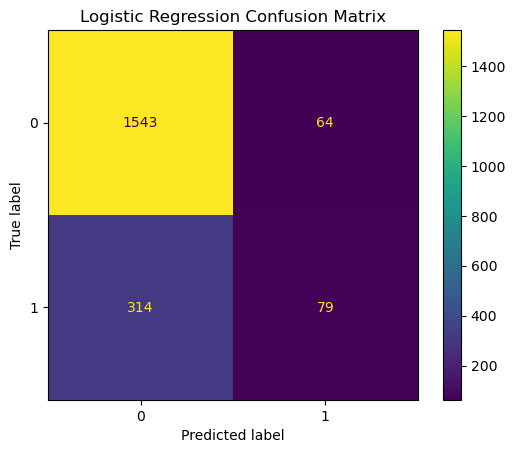

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Logistic Regression Results

The Logistic Regression model was trained using scaled customer data. The model was evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix to assess its predictive performance.

## Random Forest Classifier

This section builds a Random Forest Classifier model and evaluates its performance using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [18]:
y_pred_rf = rf_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Accuracy: 0.8665
Precision: 0.7581967213114754
Recall: 0.4707379134860051
F1 Score: 0.5808477237048666


In [20]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[1548   59]
 [ 208  185]]


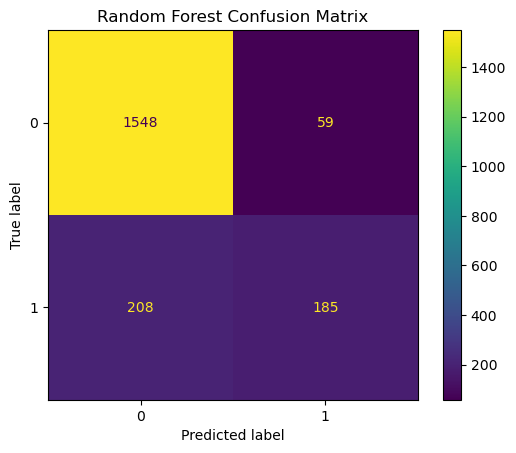

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Model Comparison

The performance of Logistic Regression and Random Forest Classifier models was compared using Accuracy, Precision, Recall, and F1 Score. The results are summarized below.

In [22]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Logistic Regression": [0.811, 0.5524, 0.2010, 0.2948],
    "Random Forest": [0.8665, 0.7582, 0.4708, 0.5808]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8110,0.8665
1,Precision,0.5524,0.7582
2,Recall,0.2010,0.4708
3,F1 Score,0.2948,0.5808


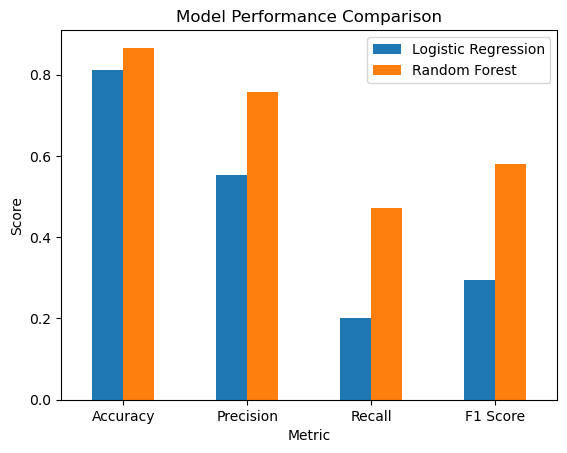

In [23]:
import matplotlib.pyplot as plt

comparison.set_index("Metric").plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

## Conclusion

The Random Forest Classifier achieved better performance than the Logistic Regression model across all evaluation metrics.

Random Forest achieved an accuracy of 86.65%, precision of 75.82%, recall of 47.08%, and an F1 score of 58.08%, outperforming Logistic Regression in predicting customer churn.

The results indicate that Random Forest is more effective at capturing complex patterns in customer behaviour and is therefore the preferred model for this customer churn prediction system.